# 1. **Business Problem & Project Objective**

**Business Problem**:
Credit card fraud is a significant challenge for financial institutions because fraudulent transactions can result in financial losses, while the detection process can also create operational costs when legitimate transactions are incorrectly flagged for investigation.
A fraud detection system therefore needs to achieve two objectives simultaneously: identify as many fraudulent transactions as possible while limiting the number of legitimate transactions incorrectly flagged as suspicious.
The highly imbalanced nature of fraud data makes this particularly challenging. In a typical transaction dataset, legitimate transactions greatly outnumber fraudulent ones, meaning that a model can achieve very high accuracy while still failing to detect a substantial proportion of fraudulent activity.

**Project Objective**:
The objective of this project is to develop and evaluate machine-learning models for credit card fraud detection, with a particular focus on the trade-off between fraud detection and false-positive investigation workload.The project will:
- Analyse the characteristics of fraudulent and legitimate transactions.
- Identify patterns and features associated with fraudulent activity.
- Develop and compare multiple machine-learning classification models.
- Evaluate models using metrics appropriate for highly imbalanced data, including precision, recall, F1-score, ROC-AUC and PR-AUC.
- Optimise the fraud-probability threshold rather than relying solely on the default 0.50 classification threshold.
- Assess the potential financial impact of detected and missed fraudulent transactions.
- Explore how different assumptions about investigation costs affect the preferred operating threshold.
- Develop a risk segmentation framework that translates model probabilities into potential business actions.



# **Business Question**: 
Can machine learning identify fraudulent credit card transactions effectively while maintaining a manageable false-positive investigation workload and minimising potential financial exposure?

# 2. **Dataset Overview**

This project uses the Credit Card Fraud Detection dataset, containing anonymised credit card transactions. The dataset includes transaction time, transaction amount, 28 anonymised numerical features (V1–V28), and a binary target variable indicating whether a transaction is fraudulent.
The V1–V28 variables are anonymised principal components, so their underlying real-world business meaning is not directly available. Consequently, the analysis focuses on their statistical and predictive relationship with fraud rather than assigning specific business interpretations to individual components.
Before modelling, the dataset will be assessed for data quality, missing values, duplicate observations, class imbalance and other characteristics that could affect model development.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("creditcard.csv")

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape

(284807, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 3. **Data Quality & Preparation**

3.1 **Missing Values**

In [10]:
df.isnull().sum()
df.isnull().sum().sum()

0

3.2 **Duplicate Transactions**

In [11]:
df.duplicated().sum()

1081

In [12]:
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


3.3 **Target Variable / Class Imbalance**

In [13]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [14]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

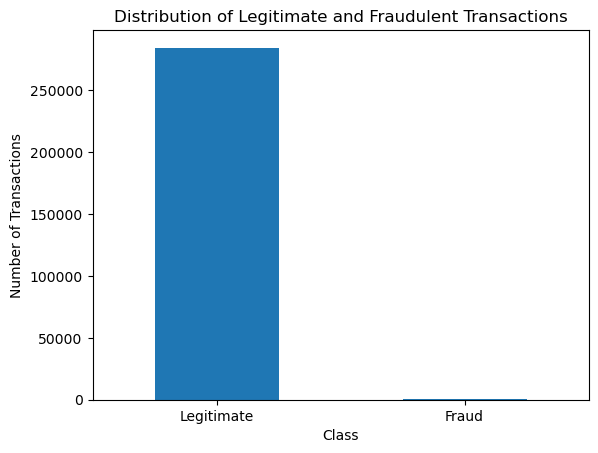

In [15]:
df["Class"].value_counts().plot(
    kind="bar",
    title="Distribution of Legitimate and Fraudulent Transactions"
)

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.show()

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [17]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [18]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

**Data Quality Summary**:

The initial data audit identified no missing values and 1,081 exact duplicate observations. Duplicate transactions were removed after confirming that identical transaction feature combinations did not contain conflicting fraud labels. The cleaned dataset contains 283,726 observations, including 473 fraudulent transactions.
The dataset is extremely imbalanced, with fraudulent transactions representing approximately 0.17% of observations. This imbalance is an important consideration for subsequent model development and evaluation. Accuracy will therefore not be treated as the primary measure of model performance.

## 4. Exploratory Data Analysis
    4.1 Fraud vs Legitimate Transaction Amounts
    4.2 Transaction amounts
    4.3 Transaction timing
    4.4 Fraud patterns

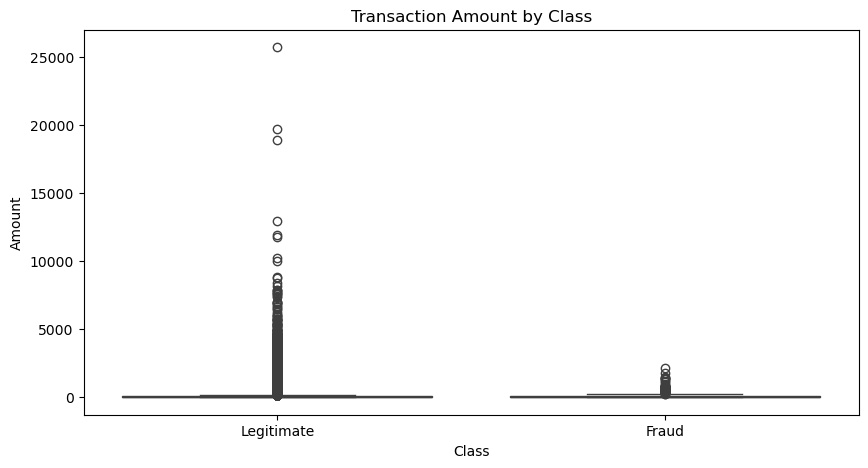

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Class")
plt.show()

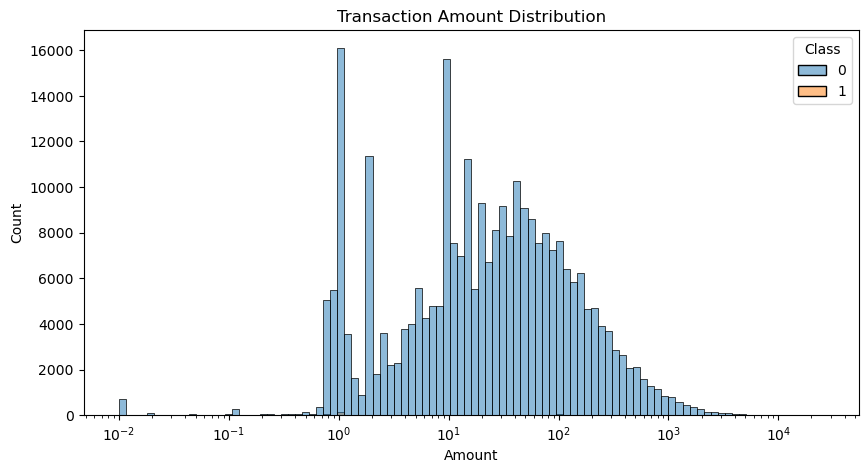

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    log_scale=True
)

plt.title("Transaction Amount Distribution")
plt.show()

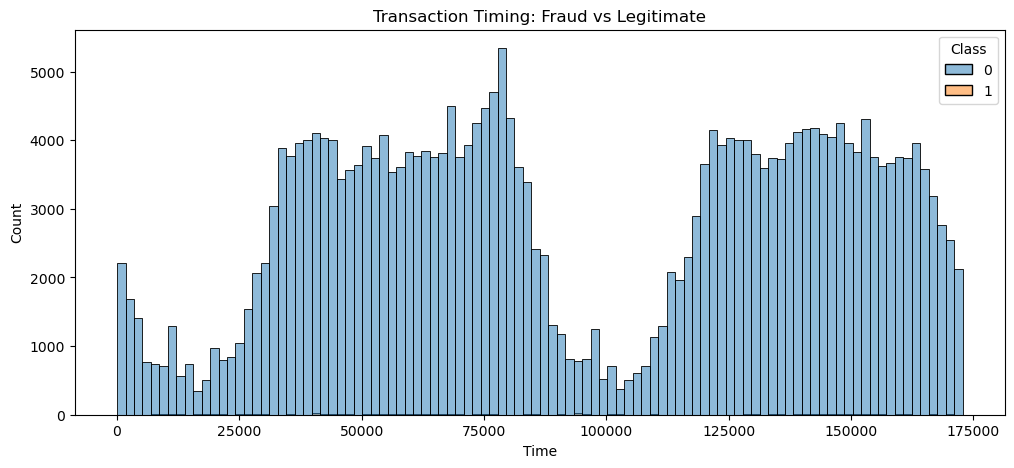

In [21]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100
)

plt.title("Transaction Timing: Fraud vs Legitimate")
plt.show()

In [22]:
df["Hour"] = (df["Time"] // 3600) % 24

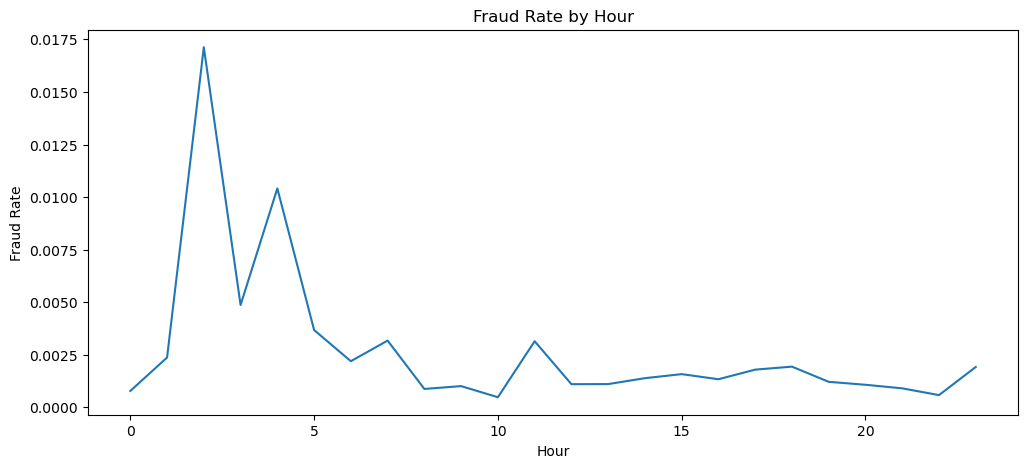

In [23]:
fraud_by_hour = df.groupby("Hour")["Class"].mean()

fraud_by_hour.plot(figsize=(12, 5))

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

In [24]:
df[df.duplicated(keep=False)].sort_values(
    by=["Time", "Amount"]
).head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0,0.0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0,0.0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0,0.0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0,0.0


In [25]:
df[df.duplicated(keep=False)]["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [26]:
df[df.duplicated(keep=False)]["Class"].value_counts(normalize=True) * 100

Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64

4.1 **Fraud vs Legitimate Transaction Amounts**

In [27]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [28]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.25
Name: Amount, dtype: float64

In [29]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

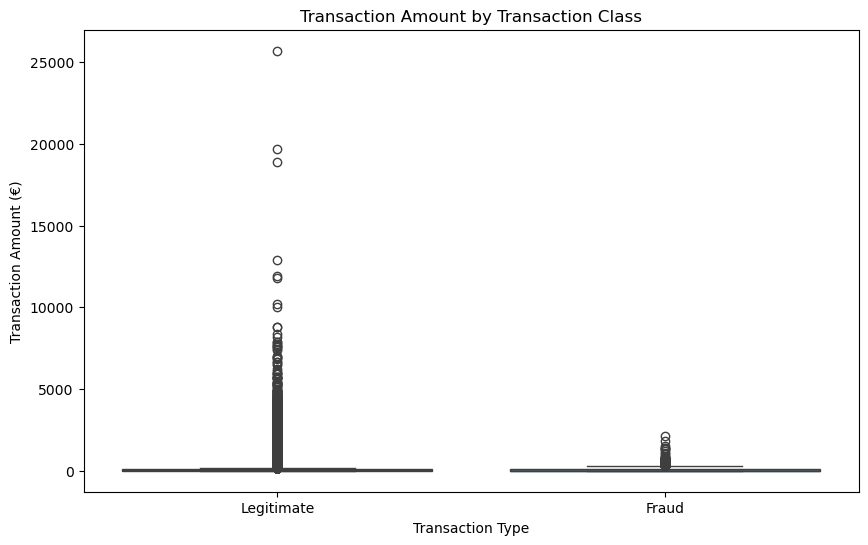

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Transaction Class")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (€)")

plt.show()

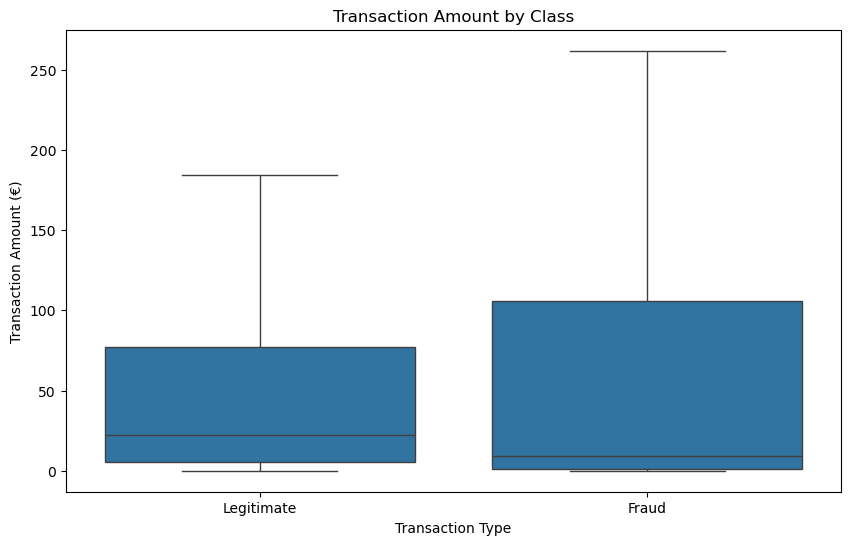

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount (€)")

plt.show()

In [32]:
df["Hour"] = (df["Time"] // 3600) % 24

4.3 **Feature Analysis**

- Mean differences
- Correlations
- KDE distributions
- Cohen's d

In [33]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_groups = (
    duplicate_rows
    .groupby(list(df.columns.drop("Class")))
    .agg(
        count=("Class", "size"),
        fraud_count=("Class", "sum")
    )
    .reset_index()
)

duplicate_groups.sort_values("count", ascending=False).head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Hour,count,fraud_count
723,163152.0,-1.203617,1.574009,2.889277,3.381404,1.538663,3.698747,0.560211,-0.150911,0.124136,...,-0.357329,-0.870174,-0.134166,0.327019,-0.042648,-0.855262,1.51,21.0,18,0
724,163152.0,-1.196037,1.585949,2.883976,3.378471,1.511706,3.717077,0.585362,-0.156001,0.122648,...,-0.355170,-0.869790,-0.133198,0.327804,-0.035702,-0.858197,7.56,21.0,18,0
766,170731.0,2.033492,0.766969,-2.107555,3.631952,1.348594,-0.499907,0.945159,-0.286392,-1.370581,...,-0.102644,0.580535,0.643637,0.347240,-0.116618,-0.078601,0.76,23.0,9,0
146,43153.0,-2.086016,2.203265,1.654339,2.941050,-1.683045,0.529728,-1.352162,1.793449,-0.723686,...,-0.035345,0.370201,0.157378,0.440341,0.210230,0.090558,0.76,11.0,9,0
281,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,18.0,6,6
287,68780.0,0.488552,-0.922367,1.673494,3.003203,-1.465758,0.749788,-0.700551,0.383919,0.511891,...,-0.222559,0.405858,0.080003,0.148637,0.022034,0.087126,282.98,19.0,5,0
286,68780.0,0.416937,-1.040707,1.631927,3.033315,-1.502318,0.763129,-0.651360,0.374298,0.507524,...,-0.255233,0.407760,0.066392,0.144683,0.015030,0.093581,320.05,19.0,5,0
288,68780.0,0.491469,-0.917547,1.675188,3.001976,-1.464269,0.749245,-0.702555,0.384311,0.512069,...,-0.221228,0.405781,0.080558,0.148798,0.022320,0.086863,281.47,19.0,5,0
285,68780.0,0.384771,-1.093859,1.613258,3.046840,-1.518739,0.769120,-0.629265,0.369976,0.505563,...,-0.269908,0.408615,0.060279,0.142908,0.011884,0.096480,336.70,19.0,5,0
284,68780.0,-0.248154,-2.139729,1.245894,3.312968,-1.841853,0.887020,-0.194520,0.284941,0.466974,...,-0.558672,0.425426,-0.060015,0.107966,-0.050019,0.153524,664.32,19.0,5,0


In [34]:
duplicate_groups["fraud_count"].value_counts()

fraud_count
0    760
2     11
6      1
4      1
Name: count, dtype: int64

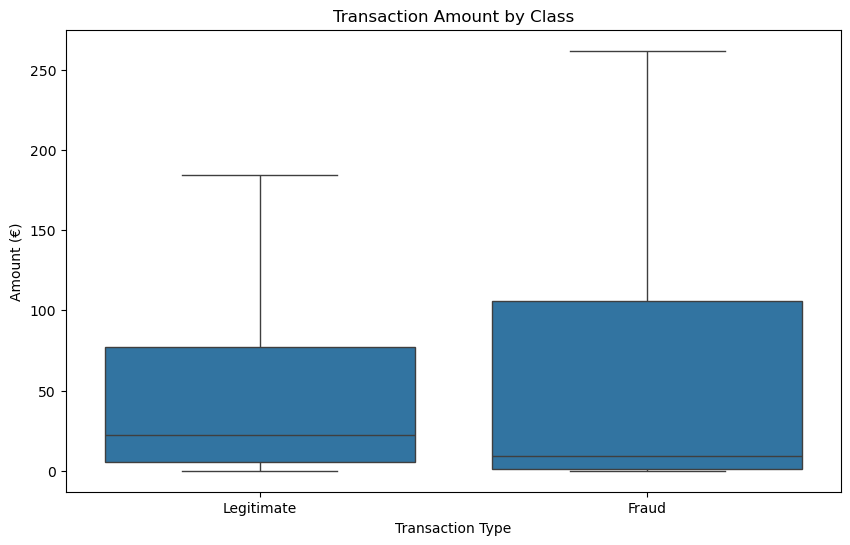

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (€)")

plt.show()

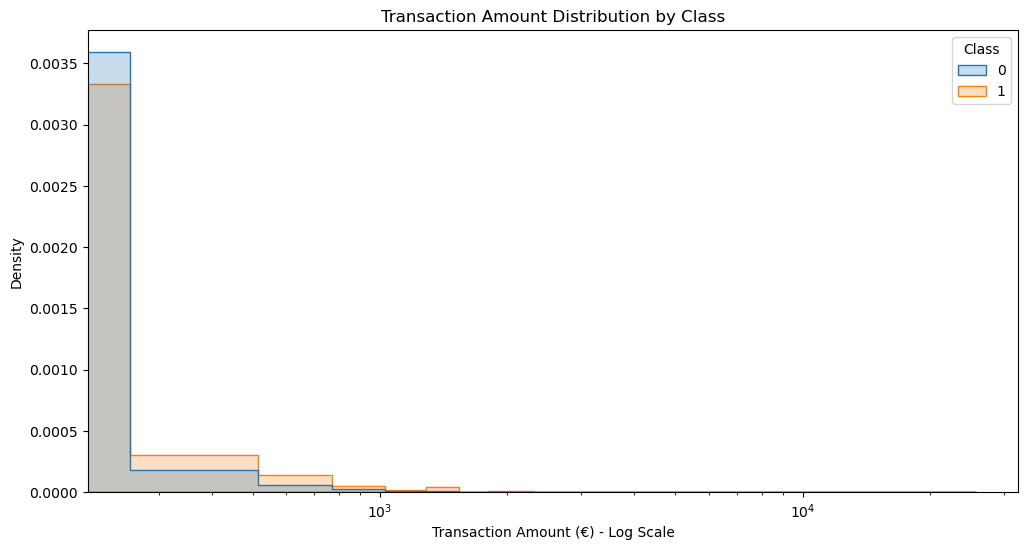

In [36]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount (€) - Log Scale")
plt.ylabel("Density")

plt.show()

In [37]:
bins = [0, 1, 5, 10, 25, 50, 100, 250, 500, 1000, 5000, float("inf")]

labels = [
    "€0–1",
    "€1–5",
    "€5–10",
    "€10–25",
    "€25–50",
    "€50–100",
    "€100–250",
    "€250–500",
    "€500–1,000",
    "€1,000–5,000",
    "€5,000+"
]

df["Amount_Band"] = pd.cut(
    df["Amount"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [38]:
fraud_by_amount = (
    df.groupby("Amount_Band", observed=True)["Class"]
    .agg(["count", "sum", "mean"])
)

fraud_by_amount

,count,sum,mean
Amount_Band,,,
€0–1,30492,181,0.005936
€1–5,38540,41,0.001064
€5–10,31232,27,0.000864
€10–25,50090,27,0.000539
€25–50,40691,30,0.000737
€50–100,37254,56,0.001503
€100–250,33873,56,0.001653
€250–500,13493,39,0.002890
"€500–1,000",6202,26,0.004192


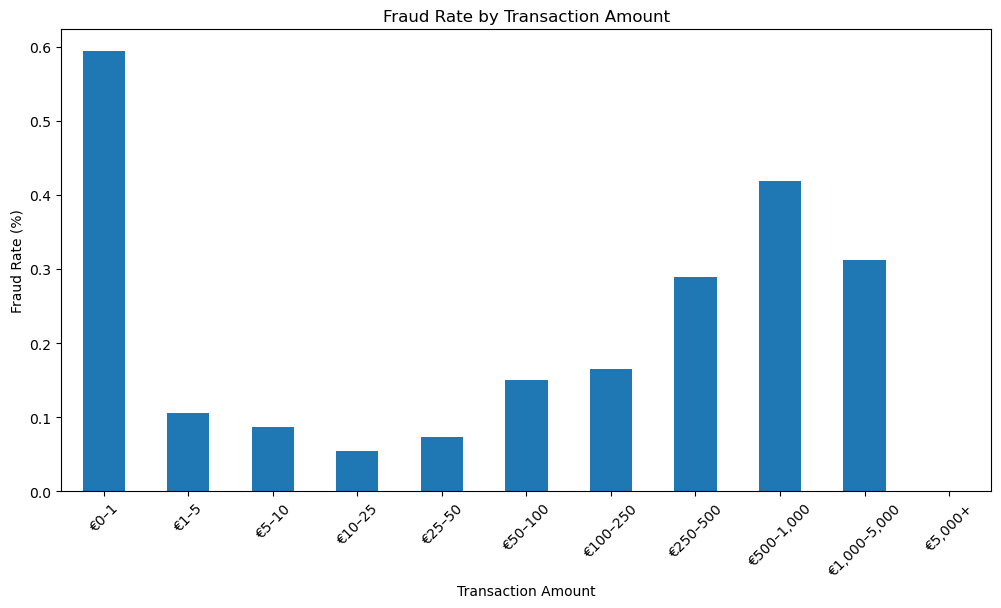

In [39]:
plt.figure(figsize=(12, 6))

fraud_by_amount["mean"].mul(100).plot(kind="bar")

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [40]:
feature_cols = [f"V{i}" for i in range(1, 29)]

class_means = df.groupby("Class")[feature_cols].mean().T

class_means.columns = ["Legitimate", "Fraud"]

class_means["Absolute_Difference"] = (
    class_means["Fraud"] - class_means["Legitimate"]
).abs()

class_means.sort_values(
    "Absolute_Difference",
    ascending=False
)

,Legitimate,Fraud,Absolute_Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


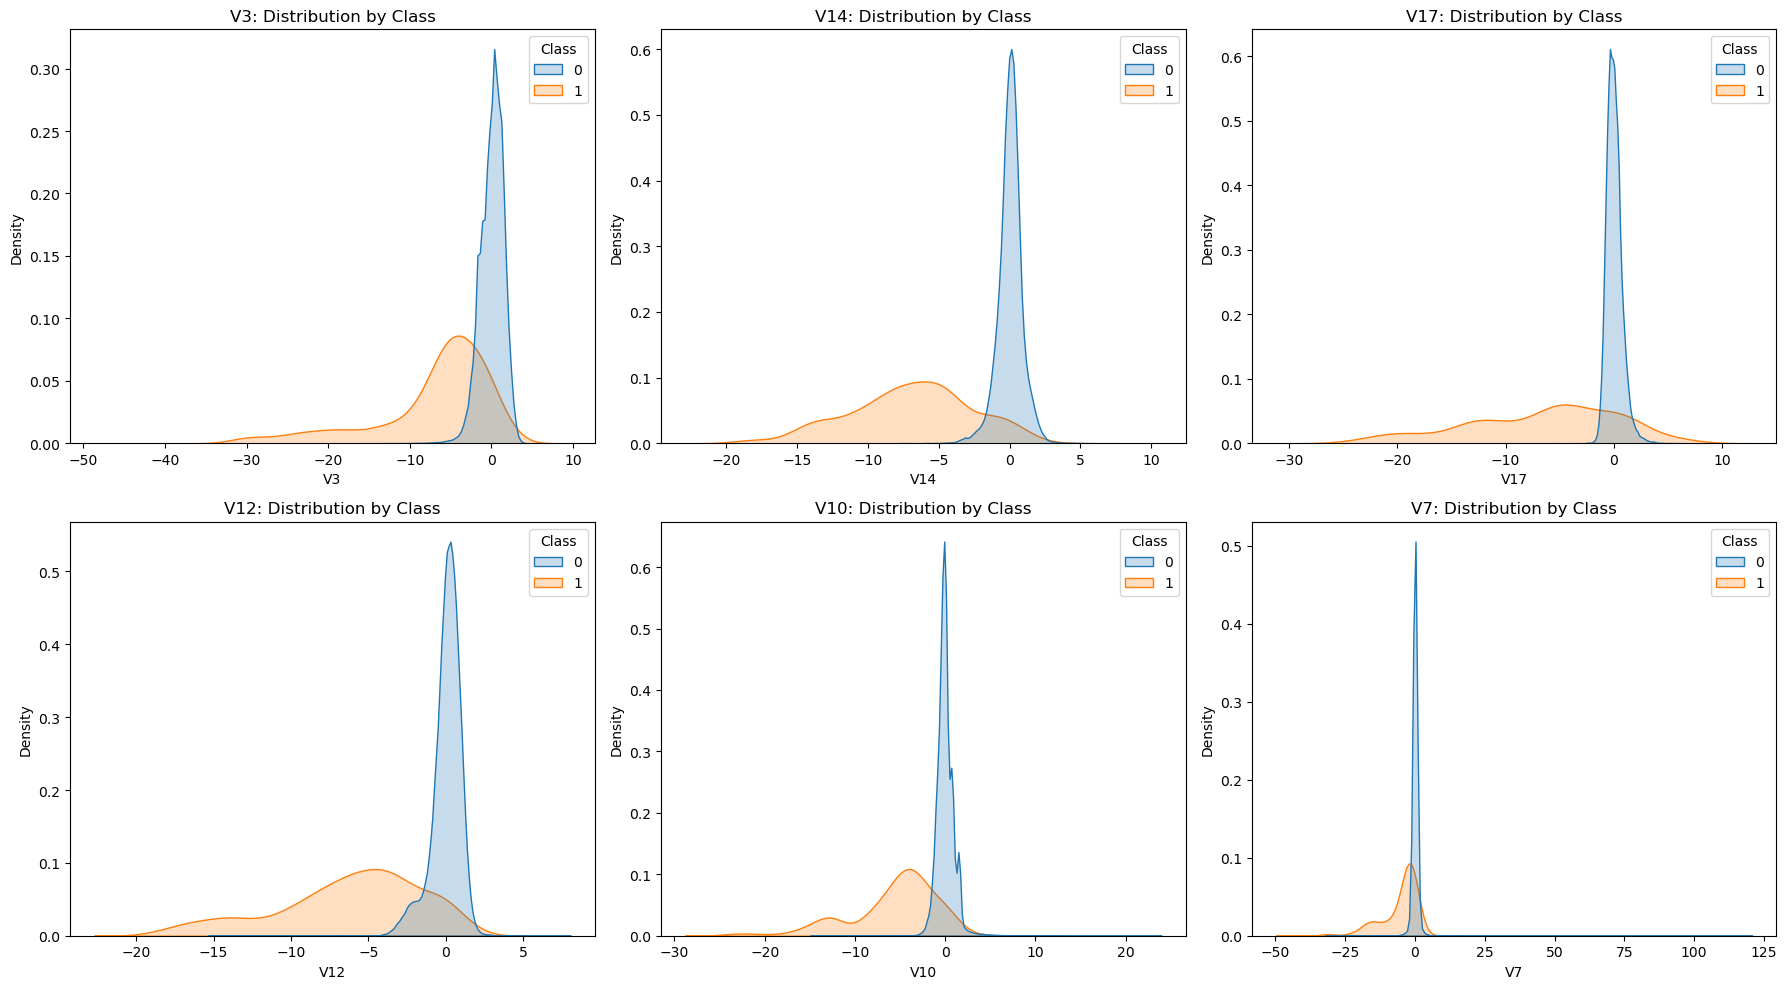

In [41]:
top_features = class_means.sort_values(
    "Absolute_Difference",
    ascending=False
).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for feature, ax in zip(top_features, axes.flatten()):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        ax=ax
    )
    
    ax.set_title(f"{feature}: Distribution by Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [42]:
correlations = (
    df[feature_cols + ["Amount", "Class"]]
    .corr()["Class"]
    .drop("Class")
    .sort_values()
)

correlations

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64

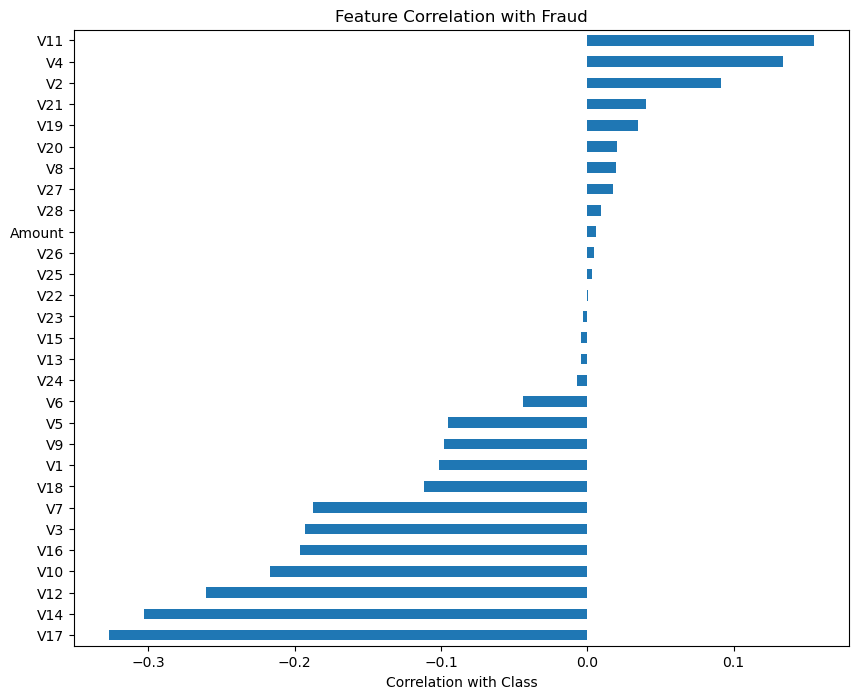

In [43]:
plt.figure(figsize=(10, 8))

correlations.plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation with Class")

plt.show()

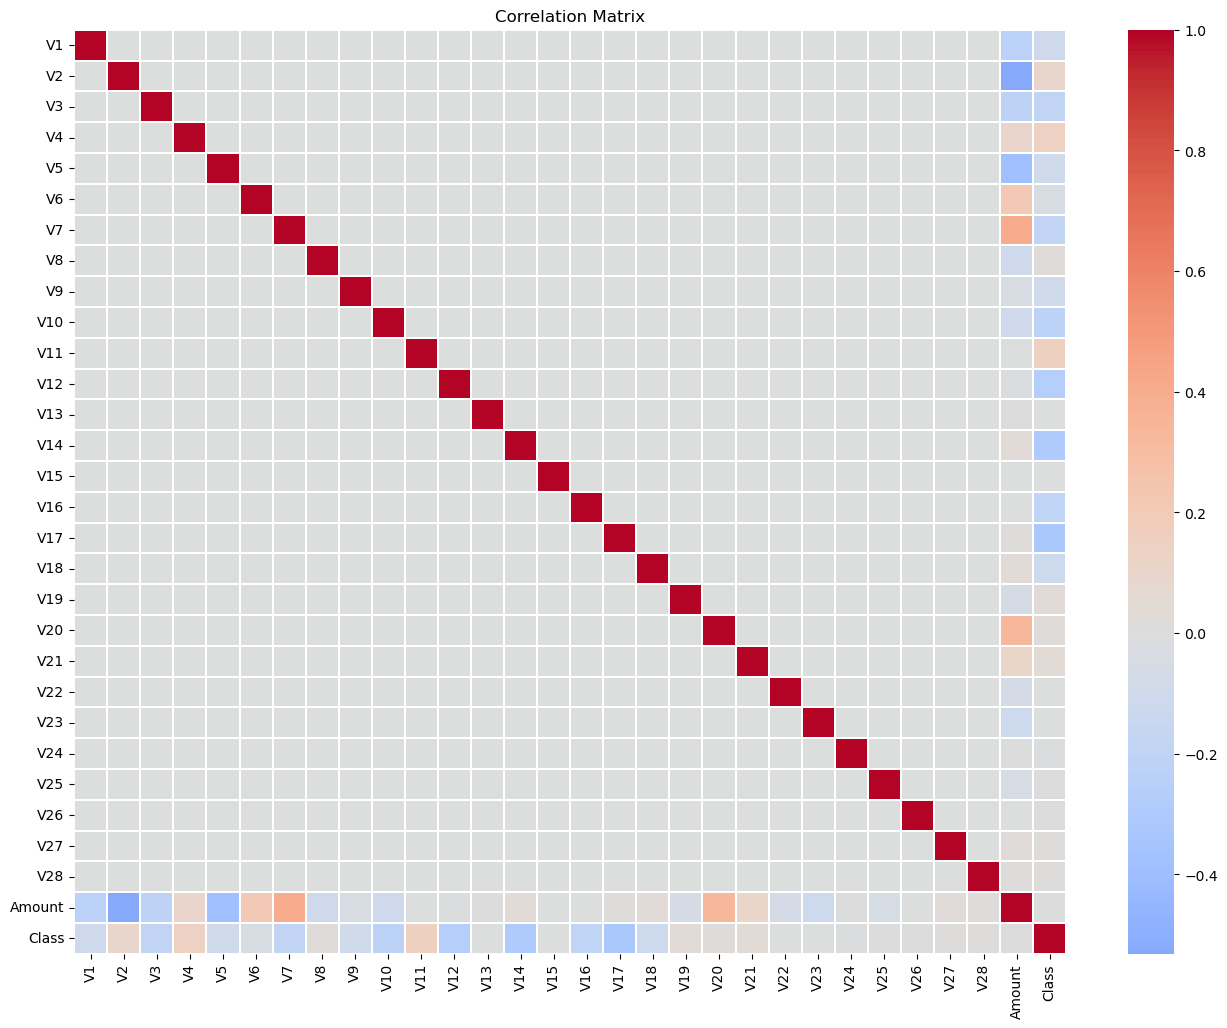

In [44]:
plt.figure(figsize=(16, 12))

corr_matrix = df[feature_cols + ["Amount", "Class"]].corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix")
plt.show()

In [45]:
hour_analysis = (
    df.groupby("Hour")["Class"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

hour_analysis

,transactions,fraud_count,fraud_rate
Hour,,,
0.0,7695,6,0.000780
1.0,4220,10,0.002370
2.0,3328,57,0.017127
3.0,3492,17,0.004868
4.0,2209,23,0.010412
5.0,2990,11,0.003679
6.0,4101,9,0.002195
7.0,7243,23,0.003175
8.0,10276,9,0.000876


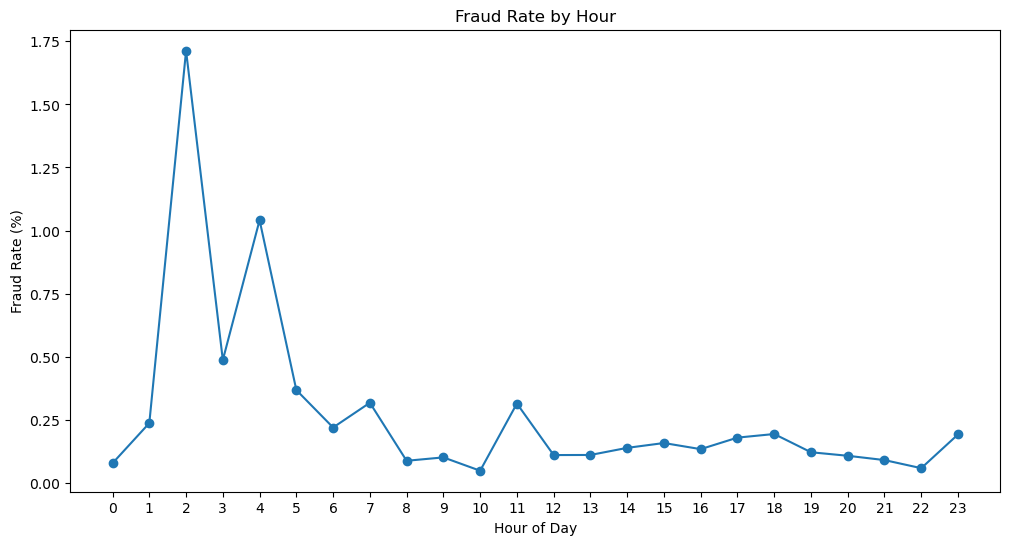

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_analysis.index,
    hour_analysis["fraud_rate"] * 100,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [47]:
results = []

for feature in feature_cols:

    legitimate = df.loc[df["Class"] == 0, feature]
    fraud = df.loc[df["Class"] == 1, feature]

    n0 = len(legitimate)
    n1 = len(fraud)

    mean_0 = legitimate.mean()
    mean_1 = fraud.mean()

    pooled_std = np.sqrt(
        (
            (n0 - 1) * legitimate.var()
            + (n1 - 1) * fraud.var()
        )
        / (n0 + n1 - 2)
    )

    cohens_d = (mean_1 - mean_0) / pooled_std

    results.append({
        "Feature": feature,
        "Mean_Legitimate": mean_0,
        "Mean_Fraud": mean_1,
        "Cohens_d": cohens_d,
        "Absolute_Cohens_d": abs(cohens_d)
    })

effect_sizes = pd.DataFrame(results)

effect_sizes = effect_sizes.sort_values(
    "Absolute_Cohens_d",
    ascending=False
)

effect_sizes

,Feature,Mean_Legitimate,Mean_Fraud,Cohens_d,Absolute_Cohens_d
16,V17,0.011535,-6.665836,-8.317624,8.317624
13,V14,0.012064,-6.971723,-7.643639,7.643639
11,V12,0.010832,-6.259393,-6.499801,6.499801
9,V10,0.009824,-5.676883,-5.350007,5.350007
15,V16,0.007164,-4.139946,-4.826913,4.826913
2,V3,0.012171,-7.033281,-4.735605,4.735605
6,V7,0.009637,-5.568731,-4.590445,4.590445
10,V11,-0.006576,3.800173,3.775043,3.775043
3,V4,-0.007860,4.542029,3.242492,3.242492
17,V18,0.003887,-2.246308,-2.701469,2.701469


## **Key EDA Findings**

**Key Findings from Exploratory Data Analysis**

The exploratory analysis identified several important characteristics of the transaction data:
1. Fraud is extremely rare.
Fraudulent transactions account for approximately 0.17% of the dataset, confirming a severe class imbalance. This means that conventional accuracy is not sufficient for evaluating fraud detection models, as a model could achieve very high accuracy while still missing a significant number of fraudulent transactions.
2. Fraudulent transaction amounts are highly skewed.
Legitimate transactions had a median amount of €22.00, compared with €9.25 for fraudulent transactions. However, the mean fraud amount was higher (€122.21 compared with €88.29 for legitimate transactions). This difference between the median and mean indicates that the fraud amount distribution is strongly right-skewed, with a relatively small number of larger fraudulent transactions. Therefore, fraudulent transactions cannot simply be characterised as being higher-value transactions.
3. Several anonymised features show strong separation between fraud and legitimate transactions.
The distributions of several PCA-derived features differed substantially between the two classes. Features including V14, V17, V12, V10, V16, V3 and V7 showed particularly large differences in their distributions.
4. V14 was particularly distinctive.
V14 demonstrated one of the strongest differences between fraudulent and legitimate transactions, with a Cohen's d of approximately -7.64. V17, V12 and V10 also demonstrated very large effect sizes. These results suggest that several anonymised PCA components contain substantial information for distinguishing fraudulent transactions.
5. The relationship between individual features and fraud is not sufficient for prediction on its own.
Although some features show strong univariate separation, fraud detection is ultimately a multivariate problem. The modelling stage is therefore required to determine whether combinations and nonlinear interactions between variables can improve fraud identification.
6. The EDA supports the use of specialised fraud-detection evaluation metrics.
Given the extreme class imbalance and the potentially different consequences of false positives and false negatives, subsequent model evaluation will focus on precision, recall, F1-score, PR-AUC and ROC-AUC, rather than relying primarily on accuracy.

## 5. **Data Preparation for Modelling**

In [134]:
feature_cols_all = [
    col for col in df.columns
    if col not in ["Class", "Hour", "Amount_Band"]
]

duplicate_label_check = (
    df.groupby(feature_cols_all)["Class"]
    .agg(["count", "nunique"])
)

duplicate_label_check[
    duplicate_label_check["nunique"] > 1
]

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count,nunique
Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,,


In [49]:
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)

print("\nOriginal class distribution:")
print(df["Class"].value_counts())

print("\nAfter removing duplicates:")
print(df_clean["Class"].value_counts())

Original shape: (284807, 33)
After removing duplicates: (283726, 33)

Original class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

After removing duplicates:
Class
0    283253
1       473
Name: count, dtype: int64


In [50]:
print("\nOriginal fraud rate:")
print(df["Class"].mean() * 100)

print("\nFraud rate after removing duplicates:")
print(df_clean["Class"].mean() * 100)


Original fraud rate:
0.1727485630620034

Fraud rate after removing duplicates:
0.1667101358352777


In [51]:
df_clean

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Amount_Band
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,€100–250
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,€1–5
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,€250–500
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,€100–250
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,€50–100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0,€0–1
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0,€10–25
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0,€50–100
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0,€5–10


5.1 **Modelling Preparation**

In [52]:
model_df = df_clean.drop(
    columns=["Class", "Hour", "Amount_Band"]
)

y = df_clean["Class"]

In [53]:
model_df.shape

(283726, 30)

5.2 **Train-Test Split**

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [56]:
model_df = df_clean.drop(
    columns=["Class", "Hour", "Amount_Band"]
)

y = df_clean["Class"]

print("X shape:", model_df.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    model_df,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#A stratified 80/20 train-test split was used to preserve the proportion of fraudulent transactions in both datasets. 
#This is particularly important because fraud represents less than 0.2% of observations.

In [58]:
print("Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training set:
Class
0    226602
1       378
Name: count, dtype: int64
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Test set:
Class
0    56651
1       95
Name: count, dtype: int64
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


## 6. **Model Development**



## 6.1 **Logistic Regression - Baseline**

Logistic Regression was selected as the baseline because it provides a relatively simple and interpretable classification approach. Establishing a baseline allows the performance of more complex models to be evaluated against a straightforward benchmark.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [60]:
logistic_baseline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [61]:
y_pred = logistic_baseline.predict(X_test)
y_prob = logistic_baseline.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

Accuracy: 0.9991188806259472
Precision: 0.8461538461538461
Recall: 0.5789473684210527
F1 Score: 0.6875
ROC-AUC: 0.9560466717268892
PR-AUC: 0.6919665484964556


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



**Interpretation**:
The baseline Logistic Regression model achieved very high accuracy but detected only 57.89% of fraudulent transactions at the default 0.50 threshold. This demonstrates why accuracy alone is unsuitable for this problem. Although the model achieved relatively high precision, its recall indicates that a substantial proportion of fraudulent transactions would remain undetected.

In [64]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56641    10]
 [   40    55]]


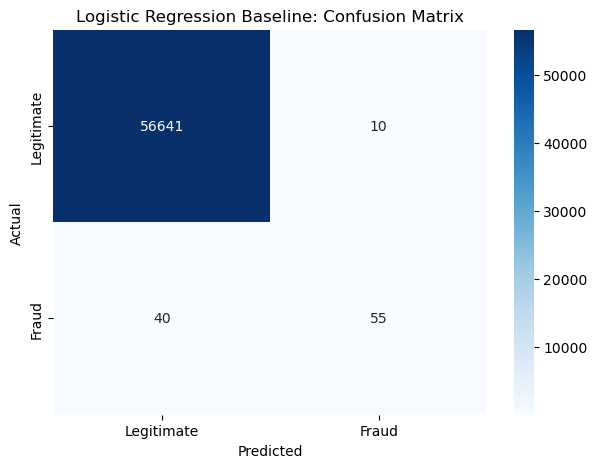

In [65]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Baseline: Confusion Matrix")

plt.show()

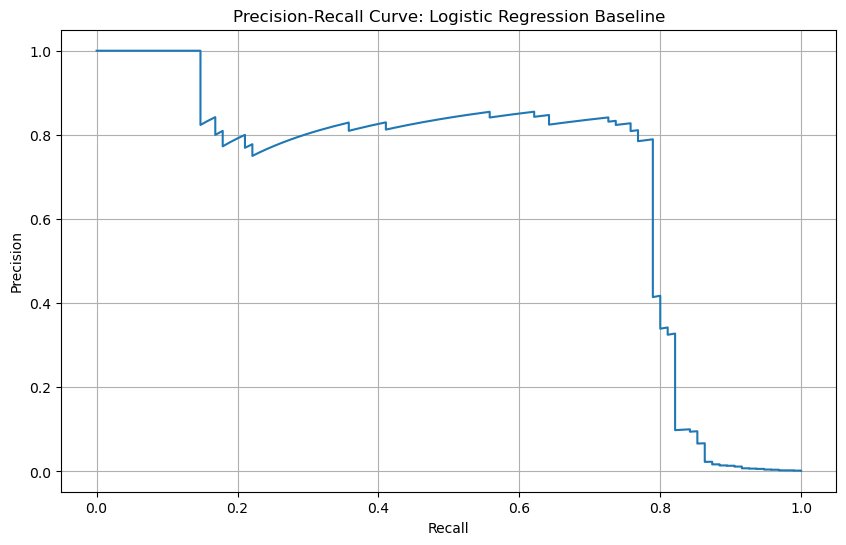

In [66]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(10, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Logistic Regression Baseline")

plt.grid()
plt.show()

In [67]:
threshold_results = []

for threshold in [0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]:

    predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "Flagged": predictions.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1,Flagged
0,0.50,0.846154,0.578947,0.687500,65
1,0.40,0.852941,0.610526,0.711656,68
2,0.30,0.835616,0.642105,0.726190,73
3,0.20,0.833333,0.684211,0.751445,78
4,0.10,0.833333,0.736842,0.782123,84
5,0.05,0.808989,0.757895,0.782609,89
6,0.02,0.641026,0.789474,0.707547,117
7,0.01,0.474684,0.789474,0.592885,158


In [68]:
threshold = 0.05

y_pred_005 = (y_prob >= threshold).astype(int)

cm_005 = confusion_matrix(y_test, y_pred_005)

print(cm_005)

[[56634    17]
 [   23    72]]


In [69]:
tn, fp, fn, tp = cm_005.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 56634
False Positives: 17
False Negatives: 23
True Positives: 72


## 6.2 **Balanced Logistic Regression**

In [70]:
logistic_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

logistic_balanced.fit(X_train, y_train)

y_pred_balanced = logistic_balanced.predict(X_test)
y_prob_balanced = logistic_balanced.predict_proba(X_test)[:, 1]

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1:", f1_score(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))
print("PR-AUC:", average_precision_score(y_test, y_prob_balanced))

Accuracy: 0.9753110351390406
Precision: 0.05638586956521739
Recall: 0.8736842105263158
F1: 0.10593490746649649
ROC-AUC: 0.9656548079701293
PR-AUC: 0.6719244530518995


**Interpretation**:
Applying class weighting substantially increased fraud recall from 57.89% to 87.37%. However, precision fell dramatically to 5.64%, producing a large number of false positives. Therefore, while class weighting improved the model's ability to detect fraud, the resulting investigation workload would be impractical at the default classification threshold.

In [72]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(cm_balanced)

tn, fp, fn, tp = cm_balanced.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

[[55262  1389]
 [   12    83]]
True Negatives: 55262
False Positives: 1389
False Negatives: 12
True Positives: 83


In [73]:
threshold_results_balanced = []

for threshold in [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]:

    predictions = (y_prob_balanced >= threshold).astype(int)

    threshold_results_balanced.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Flagged": predictions.sum()
    })

threshold_balanced_df = pd.DataFrame(threshold_results_balanced)

threshold_balanced_df

,Threshold,Precision,Recall,F1,Flagged
0,0.90,0.262458,0.831579,0.398990,301
1,0.80,0.160321,0.842105,0.269360,499
2,0.70,0.115760,0.873684,0.204433,717
3,0.60,0.078822,0.873684,0.144599,1053
4,0.50,0.056386,0.873684,0.105935,1472
5,0.40,0.039981,0.873684,0.076462,2076
6,0.30,0.026757,0.873684,0.051924,3102
7,0.20,0.016721,0.915789,0.032843,5203
8,0.10,0.008682,0.936842,0.017205,10251
9,0.05,0.004930,0.957895,0.009809,18460


## 6.3 **Random Forest**

Why Random Forest?
Random Forest was introduced to capture nonlinear relationships and interactions between features that may not be adequately represented by Logistic Regression. It also provides an ensemble-based approach that combines predictions from multiple decision trees.

In [79]:
from sklearn.ensemble import RandomForestClassifier
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:, 1]

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Accuracy: 0.9995065731505305
Precision: 0.971830985915493
Recall: 0.7263157894736842
F1: 0.8313253012048193
ROC-AUC: 0.9239444837225895
PR-AUC: 0.7875807224017503


**Interpretation**:
Random Forest substantially improved precision and F1-score compared with the Logistic Regression models. It achieved 97.18% precision and 72.63% recall, demonstrating a stronger balance between detecting fraud and limiting false positives.

In [81]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

tn, fp, fn, tp = cm_rf.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

[[56649     2]
 [   26    69]]
True Negatives: 56649
False Positives: 2
False Negatives: 26
True Positives: 69


In [82]:
threshold_results_rf = []

for threshold in [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]:

    predictions = (y_prob_rf >= threshold).astype(int)

    threshold_results_rf.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Flagged": predictions.sum()
    })

threshold_rf_df = pd.DataFrame(threshold_results_rf)

threshold_rf_df

,Threshold,Precision,Recall,F1,Flagged
0,0.90,0.978723,0.484211,0.647887,47
1,0.80,0.982759,0.600000,0.745098,58
2,0.70,0.984375,0.663158,0.792453,64
3,0.60,0.985075,0.694737,0.814815,67
4,0.50,0.971831,0.726316,0.831325,71
5,0.40,0.960000,0.757895,0.847059,75
6,0.30,0.924051,0.768421,0.839080,79
7,0.20,0.858824,0.768421,0.811111,85
8,0.10,0.755102,0.778947,0.766839,98
9,0.05,0.571429,0.800000,0.666667,133


## 6.4 **XGBoost**

**Why XGBoost?**
XGBoost was selected as a more advanced gradient-boosting approach capable of modelling complex nonlinear relationships and interactions between predictors. It was evaluated to determine whether boosting could improve upon the performance of Random Forest.

In [83]:
%pip install xgboost
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)
y_prob_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

Note: you may need to restart the kernel to use updated packages.


In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Accuracy: 0.9995418179254926
Precision: 0.9726027397260274
Recall: 0.7473684210526316
F1: 0.8452380952380952
ROC-AUC: 0.9784611039522692
PR-AUC: 0.8284038864130472


**Interpretation**:
XGBoost produced the strongest overall performance among the models tested. It achieved 97.26% precision and 74.74% recall at the default 0.50 threshold, resulting in an F1-score of 84.52%. It also achieved the highest PR-AUC at 82.84%, which is particularly relevant given the severe class imbalance.
XGBoost was therefore selected as the primary model for subsequent threshold optimisation, financial impact analysis and risk segmentation.

In [87]:
print((y_pred_rf == y_pred_xgb).mean())
print((y_prob_rf == y_prob_xgb).mean())

0.9999647552250379
0.0


## 6.5 **Model Development Summary**

Four classification approaches were developed to assess different strategies for handling the fraud detection problem. Logistic Regression provided a baseline, while class-weighted Logistic Regression demonstrated the effect of explicitly prioritising the minority fraud class. Random Forest introduced nonlinear ensemble modelling, while XGBoost provided the strongest overall predictive performance.
The results indicate that improving fraud recall alone can lead to an excessive number of false positives. XGBoost provided the strongest balance between precision and recall at the default threshold and achieved the highest PR-AUC. It was therefore selected for further threshold and financial analysis.

In [88]:
print(type(xgb_baseline))
print(type(rf_baseline))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [90]:
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("RF PR-AUC:", average_precision_score(y_test, y_prob_rf))
print("XGB PR-AUC:", average_precision_score(y_test, y_prob_xgb))

RF ROC-AUC: 0.9239444837225895
XGB ROC-AUC: 0.9784611039522692
RF PR-AUC: 0.7875807224017503
XGB PR-AUC: 0.8284038864130472


## 7. **Threshold Optimisation**

## 7.1 Why Optimise the Classification Threshold?

The default classification threshold for binary classification is typically 0.50. However, in fraud detection, this threshold may not provide the most appropriate balance between detecting fraud and limiting false-positive investigations.
The XGBoost model produces a probability between 0 and 1 representing the estimated likelihood that a transaction is fraudulent. A threshold is then applied to convert this probability into a binary decision. Lowering the threshold generally increases fraud detection but can also increase false positives.

## 7.2 Precision-Recall Threshold Analysis


In [139]:
threshold_results_xgb = []

for threshold in [0.90, 0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]:

    predictions = (y_prob_xgb >= threshold).astype(int)

    threshold_results_xgb.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Flagged": predictions.sum()
    })

threshold_xgb_df = pd.DataFrame(threshold_results_xgb)

threshold_xgb_df

,Threshold,Precision,Recall,F1,Flagged
0,0.90,0.969231,0.663158,0.787500,65
1,0.80,0.970588,0.694737,0.809816,68
2,0.70,0.971831,0.726316,0.831325,71
3,0.60,0.971831,0.726316,0.831325,71
4,0.50,0.972603,0.747368,0.845238,73
5,0.40,0.934211,0.747368,0.830409,76
6,0.30,0.922078,0.747368,0.825581,77
7,0.20,0.925000,0.778947,0.845714,80
8,0.10,0.863636,0.800000,0.830601,88
9,0.05,0.767677,0.800000,0.783505,99


**Interpretation**:
Lowering the threshold increases the number of transactions classified as potentially fraudulent. This generally improves recall but eventually causes precision to deteriorate as more legitimate transactions are flagged.

## 7.3 Selecting the Operating Threshold

In [92]:
import numpy as np

thresholds = np.arange(0.01, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:

    predictions = (y_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Flagged": predictions.sum()
    })

xgb_threshold_df = pd.DataFrame(threshold_results)

# Keep thresholds with at least 90% precision
valid_thresholds = xgb_threshold_df[
    xgb_threshold_df["Precision"] >= 0.90
]

# Find the threshold with the highest recall
best_threshold = valid_thresholds.loc[
    valid_thresholds["Recall"].idxmax()
]

best_threshold

Threshold     0.140000
Precision     0.903614
Recall        0.789474
F1            0.842697
Flagged      83.000000
Name: 13, dtype: float64

**Interpretation**:
A threshold of 0.14 was selected as the operating point because it maximised recall while maintaining a minimum precision of 90%. At this threshold, 75 of the 95 fraudulent transactions in the test set were identified, while only 8 legitimate transactions were incorrectly flagged.

In [93]:
threshold = 0.14

y_pred_xgb_014 = (y_prob_xgb >= threshold).astype(int)

cm_xgb_014 = confusion_matrix(y_test, y_pred_xgb_014)

print(cm_xgb_014)

tn, fp, fn, tp = cm_xgb_014.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

[[56643     8]
 [   20    75]]
True Negatives: 56643
False Positives: 8
False Negatives: 20
True Positives: 75


## 7.4 Threshold Interpretation

The threshold analysis demonstrates that the probability threshold is a business decision rather than simply a technical parameter. A lower threshold may be appropriate when the cost of missing fraud is high and additional investigations are relatively inexpensive. Conversely, a higher threshold may be preferable when investigation capacity or customer-friction costs are more restrictive.

## **8. Financial Impact Analysis**

## 8.1 Why Financial Impact Matters

Fraud detection performance should not be evaluated solely by the number of transactions correctly classified. The financial value associated with fraudulent transactions provides an additional perspective on model effectiveness.
Therefore, the selected XGBoost threshold was evaluated based on the value of fraudulent transactions detected and the value of fraudulent transactions that remained undetected.

In [94]:
# Add predictions to the test set
test_results = X_test.copy()

test_results["Actual_Class"] = y_test.values
test_results["Fraud_Probability"] = y_prob_xgb
test_results["Predicted_Class"] = y_pred_xgb_014

# Correctly detected fraud
detected_fraud = test_results[
    (test_results["Actual_Class"] == 1) &
    (test_results["Predicted_Class"] == 1)
]

# Missed fraud
missed_fraud = test_results[
    (test_results["Actual_Class"] == 1) &
    (test_results["Predicted_Class"] == 0)
]

print("Detected fraud transactions:", len(detected_fraud))
print("Missed fraud transactions:", len(missed_fraud))

print("Detected fraud value:", detected_fraud["Amount"].sum())
print("Missed fraud value:", missed_fraud["Amount"].sum())

print("Total fraud value:", 
      detected_fraud["Amount"].sum() + missed_fraud["Amount"].sum())

print(
    "Monetary value recall:",
    detected_fraud["Amount"].sum() /
    (detected_fraud["Amount"].sum() + missed_fraud["Amount"].sum())
)

Detected fraud transactions: 75
Missed fraud transactions: 20
Detected fraud value: 10965.930000000002
Missed fraud value: 3800.38
Total fraud value: 14766.310000000001
Monetary value recall: 0.7426317069057876


In [95]:
threshold_financial_results = []

for threshold in np.arange(0.01, 1.00, 0.01):

    predictions = (y_prob_xgb >= threshold).astype(int)

    temp = X_test.copy()
    temp["Actual_Class"] = y_test.values
    temp["Predicted_Class"] = predictions

    detected = temp[
        (temp["Actual_Class"] == 1) &
        (temp["Predicted_Class"] == 1)
    ]

    missed = temp[
        (temp["Actual_Class"] == 1) &
        (temp["Predicted_Class"] == 0)
    ]

    total_fraud_value = (
        detected["Amount"].sum() +
        missed["Amount"].sum()
    )

    detected_value = detected["Amount"].sum()

    threshold_financial_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Flagged": predictions.sum(),
        "Fraud_Value_Detected": detected_value,
        "Fraud_Value_Missed": missed["Amount"].sum(),
        "Monetary_Recall": detected_value / total_fraud_value
    })

financial_threshold_df = pd.DataFrame(threshold_financial_results)

financial_threshold_df.head()

,Threshold,Precision,Recall,F1,Flagged,Fraud_Value_Detected,Fraud_Value_Missed,Monetary_Recall
0,0.01,0.350649,0.852632,0.496933,231,11444.55,3321.76,0.775045
1,0.02,0.583942,0.842105,0.689655,137,11443.79,3322.52,0.774993
2,0.03,0.661017,0.821053,0.732394,118,11436.24,3330.07,0.774482
3,0.04,0.740385,0.810526,0.773869,104,10984.97,3781.34,0.743921
4,0.05,0.767677,0.800000,0.783505,99,10965.93,3800.38,0.742632


**Intrepretation**:
At the selected threshold of 0.14, the model identified 75 of the 95 fraudulent transactions in the test set. These transactions represented €10,965.93 of fraudulent transaction value, equivalent to a monetary recall of 74.26%.
However, €3,800.38 of fraudulent transaction value remained in transactions that the model did not identify. This demonstrates why transaction-level recall and monetary recall provide different perspectives on fraud detection performance.

## 8.2 **Business Interpretation**

From a financial-risk perspective, the model provides a mechanism for prioritising transactions for investigation rather than treating all transactions equally. The selected threshold identifies a relatively small number of transactions for review while capturing a substantial proportion of both fraudulent transactions and fraudulent transaction value.
However, the appropriate threshold ultimately depends on the relative cost of missed fraud, false-positive investigations and customer friction. This motivates the subsequent cost-sensitive threshold analysis.

In [96]:
financial_valid = financial_threshold_df[
    financial_threshold_df["Precision"] >= 0.90
]

financial_best = financial_valid.loc[
    financial_valid["Monetary_Recall"].idxmax()
]

financial_best

Threshold                   0.140000
Precision                   0.903614
Recall                      0.789474
F1                          0.842697
Flagged                    83.000000
Fraud_Value_Detected    10965.930000
Fraud_Value_Missed       3800.380000
Monetary_Recall             0.742632
Name: 13, dtype: float64

### 10. **Fraud Risk Segmentation**

## 10.1 Risk Segmentation

Rather than treating fraud detection as a simple binary classification problem, predicted fraud probabilities can be converted into risk bands.

The following risk bands are used for the analysis:

- Low Risk: probability < 1%
- Moderate Risk: probability between 1% and 5%
- Elevated Risk: probability between 5% and 14%
- High Risk: probability ≥ 14%

These bands are analytical categories developed for this project and should not be interpreted as standard banking thresholds.holds.

In [97]:
# Create a dataframe containing the test-set results
risk_df = X_test.copy()

risk_df["Actual_Class"] = y_test.values
risk_df["Fraud_Probability"] = y_prob_xgb

# Summary of predicted probabilities by actual class
risk_df.groupby("Actual_Class")["Fraud_Probability"].describe()

,count,mean,std,min,25%,50%,75%,max
Actual_Class,,,,,,,,
0,56651.0,0.000282,0.006937,0.000001,0.000018,0.000038,0.000096,0.961778
1,95.0,0.717956,0.399811,0.000035,0.418718,0.949102,0.982395,0.996385


In [99]:
risk_df["Risk_Band"] = pd.cut(
    risk_df["Fraud_Probability"],
    bins=[-np.inf, 0.01, 0.05, 0.14, np.inf],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "Elevated Risk",
        "High Risk"
    ]
)

risk_df["Risk_Band"].value_counts().sort_index()

Risk_Band
Low Risk         56515
Moderate Risk      132
Elevated Risk       16
High Risk           83
Name: count, dtype: int64

## 11.2 Risk Band Analysis

The risk segmentation shows a strong concentration of fraudulent transactions within the High Risk category.

The High Risk group contains only 83 transactions but includes 75 fraudulent transactions, resulting in an observed fraud rate of 90.36%. These transactions account for €10,965.93 of fraudulent transaction value, representing 74.26% of the total fraudulent value in the test set.

In contrast, the Low Risk group contains the majority of transactions but has a substantially lower observed fraud rate of 0.0248%.

However, Low Risk should not be interpreted as "fraud-free". Fourteen fraudulent transactions remain within this group, representing €3,321.76 of fraudulent transaction value.

In [100]:
risk_summary = risk_df.groupby("Risk_Band", observed=True).agg(
    Transactions=("Actual_Class", "count"),
    Fraud_Cases=("Actual_Class", "sum"),
    Total_Amount=("Amount", "sum"),
    Average_Amount=("Amount", "mean")
)

risk_summary

,Transactions,Fraud_Cases,Total_Amount,Average_Amount
Risk_Band,,,,
Low Risk,56515,14,4969117.62,87.925641
Moderate Risk,132,5,31881.72,241.528182
Elevated Risk,16,1,1915.00,119.687500
High Risk,83,75,36977.86,445.516386


In [101]:
risk_summary = risk_df.groupby(
    "Risk_Band",
    observed=True
).agg(
    Transactions=("Actual_Class", "count"),
    Fraud_Cases=("Actual_Class", "sum"),
    Total_Amount=("Amount", "sum"),
    Fraud_Amount=("Amount", lambda x: x[risk_df.loc[x.index, "Actual_Class"] == 1].sum())
)

risk_summary["Fraud_Rate"] = (
    risk_summary["Fraud_Cases"] /
    risk_summary["Transactions"]
)

risk_summary["Fraud_Value_Share"] = (
    risk_summary["Fraud_Amount"] /
    risk_summary["Fraud_Amount"].sum()
)

risk_summary

,Transactions,Fraud_Cases,Total_Amount,Fraud_Amount,Fraud_Rate,Fraud_Value_Share
Risk_Band,,,,,,
Low Risk,56515,14,4969117.62,3321.76,0.000248,0.224955
Moderate Risk,132,5,31881.72,478.62,0.037879,0.032413
Elevated Risk,16,1,1915.00,0.00,0.062500,0.000000
High Risk,83,75,36977.86,10965.93,0.903614,0.742632


## 11.3 Business Interpretation

The risk segmentation provides a potential framework for prioritising fraud investigations.

A possible operational interpretation would be:

| Risk Band | Potential Action |
|---|---|
| Low Risk | Normal processing and monitoring |
| Moderate Risk | Enhanced monitoring |
| Elevated Risk | Additional authentication or review |
| High Risk | Priority manual investigation or potential transaction blocking |

This framework could allow a financial institution to concentrate investigative resources on a relatively small number of transactions rather than reviewing every transaction equally.

The High Risk segment demonstrates the strongest concentration of fraud, suggesting that probability-based prioritisation could improve the efficiency of a fraud investigation process.

These actions are proposed for analytical purposes and would require validation against an institution's fraud policies, customer experience requirements and regulatory obligations.

## 11. **Cost-Sensitive Threshold Analysis**

## 11.1 Why Cost Matters

Fraud detection involves a trade-off between false positives and false negatives.

A false positive occurs when a legitimate transaction is flagged for investigation, creating an operational cost. A false negative occurs when a fraudulent transaction is not detected, potentially increasing financial exposure.

Therefore, threshold selection can also be evaluated from a cost perspective. Different assumptions about the cost of investigating a flagged transaction may lead to different optimal thresholds.

In [143]:
# Assumed investigation cost per false positive
investigation_costs = [1, 5, 10, 25, 50]

cost_results = []

for threshold in np.arange(0.01, 1.00, 0.01):

    predictions = (y_prob_xgb >= threshold).astype(int)

    temp = X_test.copy()
    temp["Actual_Class"] = y_test.values
    temp["Predicted_Class"] = predictions

    # False positives
    false_positives = temp[
        (temp["Actual_Class"] == 0) &
        (temp["Predicted_Class"] == 1)
    ]

    # False negatives
    false_negatives = temp[
        (temp["Actual_Class"] == 1) &
        (temp["Predicted_Class"] == 0)
    ]

    fp_count = len(false_positives)
    fn_count = len(false_negatives)

    # Monetary value of missed fraud
    missed_fraud_value = false_negatives["Amount"].sum()

    for cost_per_fp in investigation_costs:

        investigation_cost = fp_count * cost_per_fp

        total_cost = (
            missed_fraud_value +
            investigation_cost
        )

        cost_results.append({
            "Threshold": threshold,
            "False_Positives": fp_count,
            "False_Negatives": fn_count,
            "Missed_Fraud_Value": missed_fraud_value,
            "Investigation_Cost_Per_FP": cost_per_fp,
            "Investigation_Cost": investigation_cost,
            "Total_Cost": total_cost
        })

cost_df = pd.DataFrame(cost_results)

## 11.2 Cost-Sensitive Threshold Analysis

The cost analysis evaluates how the preferred fraud detection threshold changes under different assumptions about the operational cost of investigating a flagged transaction.

The analysis considers investigation costs of €1, €5, €10, €25 and €50 per false positive.

The total cost is calculated as:

Total Cost = Missed Fraud Value + Investigation Cost

where:

Investigation Cost = False Positives × Investigation Cost per False Positive

The missed fraud value is treated as a proxy for potential financial exposure rather than an estimate of actual bank losses.

In [103]:
best_cost_thresholds = (
    cost_df.loc[
        cost_df.groupby("Investigation_Cost_Per_FP")["Total_Cost"].idxmin()
    ]
    .sort_values("Investigation_Cost_Per_FP")
)

best_cost_thresholds

,Threshold,False_Positives,False_Negatives,Missed_Fraud_Value,Investigation_Cost_Per_FP,Investigation_Cost,Total_Cost
10,0.03,40,17,3330.07,1,40,3370.07
11,0.03,40,17,3330.07,5,200,3530.07
12,0.03,40,17,3330.07,10,400,3730.07
83,0.17,6,21,3801.38,25,150,3951.38
84,0.17,6,21,3801.38,50,300,4101.38


In [104]:
best_cost_thresholds.to_string(index=False)

print(
    best_cost_thresholds[
        [
            "Threshold",
            "False_Positives",
            "False_Negatives",
            "Missed_Fraud_Value",
            "Investigation_Cost_Per_FP",
            "Investigation_Cost",
            "Total_Cost"
        ]
    ].to_string(index=False)
)

 Threshold  False_Positives  False_Negatives  Missed_Fraud_Value  Investigation_Cost_Per_FP  Investigation_Cost  Total_Cost
      0.03               40               17             3330.07                          1                  40     3370.07
      0.03               40               17             3330.07                          5                 200     3530.07
      0.03               40               17             3330.07                         10                 400     3730.07
      0.17                6               21             3801.38                         25                 150     3951.38
      0.17                6               21             3801.38                         50                 300     4101.38


In [105]:
cost_df[
    cost_df["Investigation_Cost_Per_FP"] == 10
].sort_values("Total_Cost").head(10)

,Threshold,False_Positives,False_Negatives,Missed_Fraud_Value,Investigation_Cost_Per_FP,Investigation_Cost,Total_Cost
12,0.03,40,17,3330.07,10,400,3730.07
102,0.21,6,21,3801.38,10,60,3861.38
107,0.22,6,21,3801.38,10,60,3861.38
97,0.20,6,21,3801.38,10,60,3861.38
92,0.19,6,21,3801.38,10,60,3861.38
87,0.18,6,21,3801.38,10,60,3861.38
82,0.17,6,21,3801.38,10,60,3861.38
72,0.15,7,20,3800.38,10,70,3870.38
77,0.16,7,21,3801.38,10,70,3871.38
142,0.29,6,23,3811.60,10,60,3871.60


In [106]:
print(
    best_cost_thresholds[
        [
            "Threshold",
            "False_Positives",
            "False_Negatives",
            "Missed_Fraud_Value",
            "Investigation_Cost_Per_FP",
            "Investigation_Cost",
            "Total_Cost"
        ]
    ].to_string(index=False)
)

 Threshold  False_Positives  False_Negatives  Missed_Fraud_Value  Investigation_Cost_Per_FP  Investigation_Cost  Total_Cost
      0.03               40               17             3330.07                          1                  40     3370.07
      0.03               40               17             3330.07                          5                 200     3530.07
      0.03               40               17             3330.07                         10                 400     3730.07
      0.17                6               21             3801.38                         25                 150     3951.38
      0.17                6               21             3801.38                         50                 300     4101.38


In [107]:
for cost in investigation_costs:
    print(f"\nInvestigation cost per FP: €{cost}")
    print(
        cost_df[
            cost_df["Investigation_Cost_Per_FP"] == cost
        ]
        .sort_values("Total_Cost")
        .head(5)
        .to_string(index=False)
    )


Investigation cost per FP: €1
 Threshold  False_Positives  False_Negatives  Missed_Fraud_Value  Investigation_Cost_Per_FP  Investigation_Cost  Total_Cost
      0.03               40               17             3330.07                          1                  40     3370.07
      0.02               57               15             3322.52                          1                  57     3379.52
      0.01              150               14             3321.76                          1                 150     3471.76
      0.22                6               21             3801.38                          1                   6     3807.38
      0.21                6               21             3801.38                          1                   6     3807.38

Investigation cost per FP: €5
 Threshold  False_Positives  False_Negatives  Missed_Fraud_Value  Investigation_Cost_Per_FP  Investigation_Cost  Total_Cost
      0.03               40               17             3330.07      

## 10.3 Interpretation

The results demonstrate that the preferred threshold depends on the assumed cost of investigating false positives.

When the investigation cost is relatively low (€1–€10 per false positive), a lower threshold of approximately 0.03 is preferred. This produces more false positives but reduces the number of missed fraudulent transactions and therefore lowers the estimated total cost.

When the investigation cost increases to €25–€50 per false positive, a higher threshold of approximately 0.17–0.22 becomes preferable. This substantially reduces the number of false positives, although it results in slightly more missed fraud value.

This demonstrates that there is no universally optimal fraud detection threshold. The appropriate operating point depends on the financial institution's investigation capacity and the relative cost of missed fraud versus investigating legitimate transactions.

The cost assumptions used in this analysis are illustrative and should be replaced with institution-specific estimates in a real-world implementation.

In [108]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.9991188806,
        0.9753110351,
        0.9995065732,
        0.9995418179
    ],
    "Precision": [
        0.8461538462,
        0.0563858696,
        0.9718309859,
        0.9726027397
    ],
    "Recall": [
        0.5789473684,
        0.8736842105,
        0.7263157895,
        0.7473684211
    ],
    "F1": [
        0.6875,
        0.1059349075,
        0.8313253012,
        0.8452380952
    ],
    "ROC_AUC": [
        0.9560466717,
        0.9656548080,
        0.9239444837,
        0.9784611030
    ],
    "PR_AUC": [
        0.6919665485,
        0.6719244531,
        0.7875807224,
        0.8284038864
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.999119,0.846154,0.578947,0.687500,0.956047,0.691967
1,Balanced Logistic Regression,0.975311,0.056386,0.873684,0.105935,0.965655,0.671924
2,Random Forest,0.999507,0.971831,0.726316,0.831325,0.923944,0.787581
3,XGBoost,0.999542,0.972603,0.747368,0.845238,0.978461,0.828404


In [109]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
1,Balanced Logistic Regression,0.9753,0.0564,0.8737,0.1059,0.9657,0.6719
2,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
3,XGBoost,0.9995,0.9726,0.7474,0.8452,0.9785,0.8284


In [110]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_baseline.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.448642
10,V10,0.129432
12,V12,0.051027
4,V4,0.028259
16,V16,0.026586
7,V7,0.022961
17,V17,0.020669
18,V18,0.016076
5,V5,0.014823
3,V3,0.014598


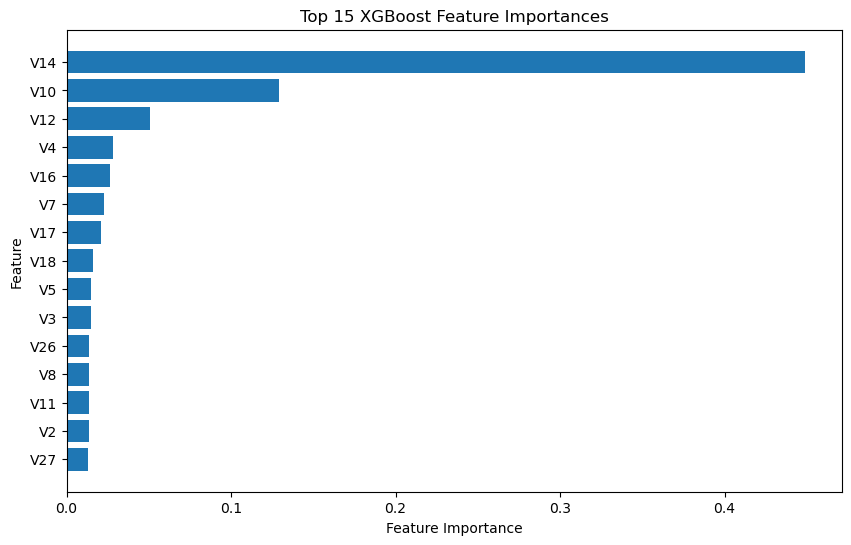

In [111]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

In [122]:
final_threshold = 0.14

y_pred_final = (y_prob_xgb >= final_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Confusion Matrix:
[[56643     8]
 [   20    75]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.79      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [123]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 56643
False Positives: 8
False Negatives: 20
True Positives: 75


In [124]:
final_threshold = 0.14

y_pred_final = (y_prob_xgb >= final_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Confusion Matrix:
[[56643     8]
 [   20    75]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.79      0.84        95

    accuracy                           1.00     56746
   macro avg       0.95      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [125]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 56643
False Positives: 8
False Negatives: 20
True Positives: 75


In [126]:
final_results = X_test.copy()

final_results["Actual_Class"] = y_test.values
final_results["Predicted_Class"] = y_pred_final
final_results["Fraud_Probability"] = y_prob_xgb

In [127]:
true_positives = final_results[
    (final_results["Actual_Class"] == 1) &
    (final_results["Predicted_Class"] == 1)
]

false_positives = final_results[
    (final_results["Actual_Class"] == 0) &
    (final_results["Predicted_Class"] == 1)
]

false_negatives = final_results[
    (final_results["Actual_Class"] == 1) &
    (final_results["Predicted_Class"] == 0)
]

total_fraud = final_results[
    final_results["Actual_Class"] == 1
]

In [128]:
detected_fraud_value = true_positives["Amount"].sum()
missed_fraud_value = false_negatives["Amount"].sum()
total_fraud_value = total_fraud["Amount"].sum()

monetary_recall = detected_fraud_value / total_fraud_value

print(f"Detected fraud value: €{detected_fraud_value:,.2f}")
print(f"Missed fraud value: €{missed_fraud_value:,.2f}")
print(f"Total fraud value: €{total_fraud_value:,.2f}")
print(f"Monetary recall: {monetary_recall:.2%}")

Detected fraud value: €10,965.93
Missed fraud value: €3,800.38
Total fraud value: €14,766.31
Monetary recall: 74.26%


In [129]:
risk_df = X_test.copy()

risk_df["Actual_Class"] = y_test.values
risk_df["Fraud_Probability"] = y_prob_xgb

risk_df["Risk_Band"] = pd.cut(
    risk_df["Fraud_Probability"],
    bins=[-np.inf, 0.01, 0.05, 0.14, np.inf],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "Elevated Risk",
        "High Risk"
    ]
)

In [131]:
risk_summary = (
    risk_df
    .groupby("Risk_Band", observed=False)
    .agg(
        Transactions=("Actual_Class", "size"),
        Fraud_Transactions=("Actual_Class", "sum"),
        Total_Amount=("Amount", "sum"),
        Fraud_Amount=("Amount", lambda x: x[risk_df.loc[x.index, "Actual_Class"] == 1].sum())
    )
    .reset_index()
)

risk_summary["Fraud_Rate"] = (
    risk_summary["Fraud_Transactions"] /
    risk_summary["Transactions"]
)

risk_summary["Fraud_Value_Share"] = (
    risk_summary["Fraud_Amount"] /
    total_fraud_value
)

risk_summary

,Risk_Band,Transactions,Fraud_Transactions,Total_Amount,Fraud_Amount,Fraud_Rate,Fraud_Value_Share
0,Low Risk,56515,14,4969117.62,3321.76,0.000248,0.224955
1,Moderate Risk,132,5,31881.72,478.62,0.037879,0.032413
2,Elevated Risk,16,1,1915.00,0.00,0.062500,0.000000
3,High Risk,83,75,36977.86,10965.93,0.903614,0.742632


## 12. **Business Recommendations**

    So what should a financial institution actually do with these results?

## 12.1 Use XGBoost as the Preferred Model

Among the models evaluated, XGBoost provided the strongest overall balance between fraud detection and false-positive control.

At the default threshold of 0.50, the model achieved a precision of 97.26%, recall of 74.74%, F1-score of 84.52%, ROC-AUC of 97.85% and PR-AUC of 82.84%.

Given the highly imbalanced nature of the dataset, PR-AUC and fraud-class precision and recall are particularly important when assessing model perfor

## 12.2 Do Not Use Accuracy as the Primary Decision Metric

The analysis demonstrates that accuracy can be misleading in highly imbalanced fraud detection problems.

Because legitimate transactions represent more than 99% of the dataset, a model can achieve very high accuracy while failing to identify a meaningful proportion of fraudulent transactions.

Therefore, fraud detection performance should be evaluated using metrics such as precision, recall, F1-score, PR-AUC and ROC-AUC, alongside financial and operational mea

## 12.3 Use a Business-Driven Classification Threshold

The default probability threshold of 0.50 should not automatically be treated as the optimal operating point.

Using a precision constraint of at least 90%, a threshold of 0.14 was selected for the final analysis. At this threshold, the model achieved:

- Precision: 90.36%
- Recall: 78.95%
- F1-score: 84.27%
- Transactions flagged: 83
- Fraud detected: 75 out of 95

This illustrates how threshold optimisation can improve the operational usefulness of a fraud detection model without changing the under

## 12.4 Prioritise Investigations Using Fraud Risk Scores

The predicted fraud probabilities can be used to prioritise transactions for investigation.

The risk segmentation demonstrated that the High Risk category contained 75 of the 95 fraudulent transactions while representing only 83 transactions in total.

This suggests that probability-based prioritisation could allow fraud investigation teams to focus resources on transactions with the highest estimated fraud

## 12.5 Evaluate Both Transaction and Monetary Impact

Fraud detection should be evaluated using both transaction-level and monetary measures.

At the selected threshold, the model detected 75 of 95 fraudulent transactions, corresponding to a transaction recall of 78.95%.

However, the detected fraudulent transaction value was €10,965.93 out of €14,766.31, giving a monetary recall of 74.26%.

This difference demonstrates why transaction counts alone may not fully capture the financial impact of a fraud detection

## 12.6 Align Thresholds With Operational Costs

The cost-sensitive analysis demonstrates that the preferred threshold changes depending on the assumed cost of investigating false positives.

Financial institutions should therefore estimate:

- cost of investigating a suspicious transaction
- cost of customer friction
- potential financial exposure from missed fraud
- investigation team capacity
- consequences of incorrectly blocking legitimate transactions

These estimates can then be incorporated into threshold selection rather than relying solely on statistical mo

## 12.7 Overall Recommendation

The analysis suggests that a fraud detection system should not be implemented as a simple binary prediction tool. Instead, the model should produce fraud probabilities that can be combined with business rules, investigation capacity and financial exposure.

XGBoost provided the strongest overall predictive performance among the models tested. A threshold of 0.14 provided a useful operating point for this analysis, identifying 75 of 95 fraudulent transactions while limiting false positives to 8.

The resulting risk segmentation also demonstrated the potential value of prioritising a small number of high-risk transactions for investigation.

However, the final threshold should ultimately be determined using institution-specific fraud costs, operational capacity and customer experience conside

# 13. Conclusion

This project investigated the use of machine learning for credit card fraud detection, with a focus on both predictive performance and business impact.

The dataset was highly imbalanced, with fraudulent transactions representing approximately 0.17% of observations. Following data quality checks and removal of duplicate observations, the cleaned dataset contained 283,726 transactions and 473 fraudulent transactions.

Several classification approaches were evaluated, including Logistic Regression, class-weighted Logistic Regression, Random Forest and XGBoost. XGBoost provided the strongest overall balance between precision and recall, achieving a PR-AUC of 82.84% and ROC-AUC of 97.85% at the default threshold.

Rather than relying on the default 0.50 probability threshold, threshold optimisation was performed. A threshold of 0.14 was selected based on maintaining precision above 90%. At this threshold, the model achieved 90.36% precision and 78.95% recall, detecting 75 of the 95 fraudulent transactions in the test set while generating 8 false positives.

The financial analysis showed that the detected fraudulent transactions represented €10,965.93 of fraudulent transaction value, compared with €3,800.38 associated with missed fraudulent transactions. This resulted in a monetary recall of 74.26%.

The cost-sensitive analysis further demonstrated that the optimal threshold depends on the relative cost of investigating false positives versus the potential financial exposure associated with missed fraud.

Finally, risk segmentation showed that the High Risk category contained 75 fraudulent transactions among only 83 transactions, representing 74.26% of the fraudulent transaction value. This demonstrates the potential for probability-based risk prioritisation to support fraud investigation teams.

Overall, the project demonstrates that effective fraud detection requires more than maximising classification accuracy. A practical solution should combine predictive modelling, threshold optimisation, financial impact analysis and risk-based prioritisation to support better operational decision-making.rations.del metrics. system. risk.lying model.sures.mance.